In [ ]:
!pip install opencv-python
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 10.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


In [ ]:
from google.colab.patches import cv2_imshow
import cv2

In [ ]:
# Import Libraries
import cv2
import time
import mediapipe as mp

In [ ]:
# Grabbing the Holistic Model from Mediapipe and
# Initializing the Model
mp_holistic = mp.solutions.holistic
holistic_model = mp_holistic.Holistic(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Initializing the drawing utils for drawing the facial landmarks on image
mp_drawing = mp.solutions.drawing_utils

In [ ]:
# (0) in VideoCapture is used to connect to your computer's default camera
capture = cv2.VideoCapture(0)

# Initializing current time and precious time for calculating the FPS
previousTime = 0
currentTime = 0

while capture.isOpened():
    # capture frame by frame
    ret, frame = capture.read()

    # resizing the frame for better view
    frame = cv2.resize(frame, (800, 600))

    # Converting the from BGR to RGB
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Making predictions using holistic model
    # To improve performance, optionally mark the image as not writeable to
    # pass by reference.
    image.flags.writeable = False
    results = holistic_model.process(image)
    image.flags.writeable = True

    # Converting back the RGB image to BGR
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Drawing the Facial Landmarks
    mp_drawing.draw_landmarks(
      image,
      results.face_landmarks,
      mp_holistic.FACEMESH_CONTOURS,
      mp_drawing.DrawingSpec(
        color=(255,0,255),
        thickness=1,
        circle_radius=1
      ),
      mp_drawing.DrawingSpec(
        color=(0,255,255),
        thickness=1,
        circle_radius=1
      )
    )

    # Drawing Right hand Land Marks
    mp_drawing.draw_landmarks(
      image,
      results.right_hand_landmarks,
      mp_holistic.HAND_CONNECTIONS
    )

    # Drawing Left hand Land Marks
    mp_drawing.draw_landmarks(
      image,
      results.left_hand_landmarks,
      mp_holistic.HAND_CONNECTIONS
    )

    # Calculating the FPS
    currentTime = time.time()
    fps = 1 / (currentTime-previousTime)
    previousTime = currentTime

    # Displaying FPS on the image
    cv2.putText(image, str(int(fps))+" FPS", (10, 70), cv2.FONT_HERSHEY_COMPLEX, 1, (0,255,0), 2)

    # Display the resulting image
    cv2.imshow("Facial and Hand Landmarks", image)

    # Enter key 'q' to break the loop
    if cv2.waitKey(5) & 0xFF == ord('q'):
        break

# When all the process is done
# Release the capture and destroy all windows
capture.release()
cv2.destroyAllWindows()

In [ ]:
# Code to access landmarks
for landmark in mp_holistic.HandLandmark:
    print(landmark, landmark.value)

print(mp_holistic.HandLandmark.WRIST.value)

0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9
10 10
11 11
12 12
13 13
14 14
15 15
16 16
17 17
18 18
19 19
20 20
0


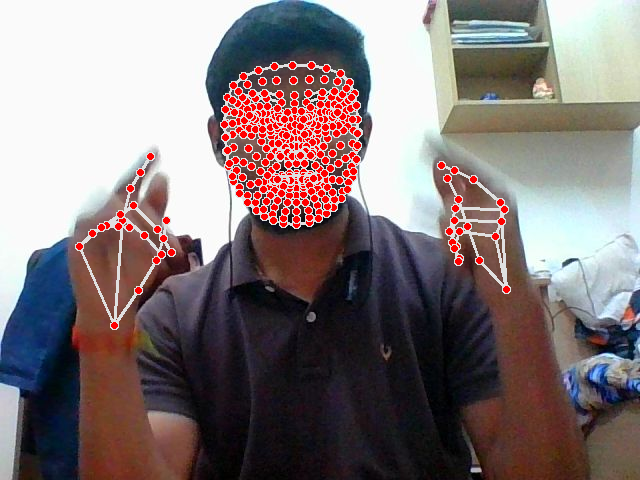

Camera closed or error: ReferenceError: capture is not defined


In [ ]:
import IPython
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import mediapipe as mp

# 1. Setup MediaPipe
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

# 2. Simplified JS Bridge (No 'innerText' to break)
def start_camera():
  js = """
    async function startCam() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      // Function to capture a frame
      window.capture = function() {
        canvas.getContext('2d').drawImage(video, 0, 0);
        return canvas.toDataURL('image/jpeg', 0.8);
      };
    }
    """
  display(IPython.display.Javascript(js))
  eval_js('startCam()')

def get_frame():
  data = eval_js('capture()')
  binary = b64decode(data.split(',')[1])
  img = cv2.imdecode(np.frombuffer(binary, dtype=np.uint8), -1)
  return img

# 3. Run the Loop
start_camera()

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while True:
        try:
            frame = get_frame()

            # Process
            results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

            # Draw
            mp_drawing.draw_landmarks(frame, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS)
            mp_drawing.draw_landmarks(frame, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
            mp_drawing.draw_landmarks(frame, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

            # Show the result in the output cell
            from google.colab.patches import cv2_imshow
            IPython.display.clear_output(wait=True)
            cv2_imshow(frame)

        except Exception as e:
            print("Camera closed or error:", e)
            break